# NS05 Tutorial - Homophily and Structural Balance

**Lecture:** NS05 - Homophily and Structural Balance  
**Reading:** Easley & Kleinberg, Chapters 4 and 5

## Learning goals

By the end of this notebook you will be able to:

1. Compute the **homophily test** and interpret the $2pq$ baseline.
2. Add a **permutation test** to decide whether an observed homophily signal is stronger than random mixing.
3. Compute **$k_{nn}(i)$**, **$k_{nn}(k)$**, and the degree assortativity coefficient $r$.
4. Simulate the **Schelling model** and measure how local preferences produce global segregation.
5. Test **strong balance** and **weak balance** on signed graphs.

## Outline

1. Homophily in a real social network.
2. Degree assortativity and neighbor-degree profiles.
3. Schelling segregation as a computational process.
4. Signed balance and polarization.

This notebook follows the lecture notation. When a question cannot be answered from a single snapshot, the notebook says so explicitly.

In [1]:
from netsci_utils import *
import pandas as pd
from itertools import combinations
from collections import defaultdict

set_seeds()
%matplotlib inline


def cross_type_fraction(G, attr_map):
    cross = sum(1 for u, v in G.edges() if attr_map[u] != attr_map[v])
    return cross / G.number_of_edges(), cross


def permutation_homophily_test(G, attr_map, n_perm=2000, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    labels = np.array([attr_map[n] for n in nodes], dtype=object)
    observed, _ = cross_type_fraction(G, attr_map)
    null_values = []

    for _ in range(n_perm):
        shuffled = labels.copy()
        rng.shuffle(shuffled)
        shuffled_map = dict(zip(nodes, shuffled))
        frac_cross, _ = cross_type_fraction(G, shuffled_map)
        null_values.append(frac_cross)

    null_values = np.array(null_values)
    p_value = (np.sum(null_values <= observed) + 1) / (n_perm + 1)
    return observed, null_values, p_value


def knn_by_degree(G):
    k_nn_i = nx.average_neighbor_degree(G)
    groups = defaultdict(list)
    for node, value in k_nn_i.items():
        groups[G.degree(node)].append(value)
    ks = np.array(sorted(groups))
    means = np.array([np.mean(groups[k]) for k in ks])
    return ks, means, k_nn_i


def signed_triangle_table(G):
    rows = []
    for triad in combinations(G.nodes(), 3):
        edges = list(combinations(triad, 2))
        if not all(G.has_edge(u, v) for u, v in edges):
            continue
        signs = [G.edges[u, v]['sign'] for u, v in edges]
        n_negative = sum(sign == -1 for sign in signs)
        rows.append({
            'triangle': triad,
            'negative_edges': n_negative,
            'balanced': np.prod(signs) > 0,
            'weakly_balanced': n_negative != 1,
        })
    return pd.DataFrame(rows)


def build_signed_complete_graph(camp_map):
    G = nx.Graph()
    for node, camp in camp_map.items():
        G.add_node(node, camp=camp)
    for u, v in combinations(G.nodes(), 2):
        sign = 1 if camp_map[u] == camp_map[v] else -1
        G.add_edge(u, v, sign=sign)
    return G


def draw_signed_graph(G, pos, ax, title, camp_colors):
    node_colors = colors_from_node_attribute(G, 'camp', camp_colors)
    draw_graph(
        G,
        pos=pos,
        ax=ax,
        with_labels=True,
        node_color=node_colors,
        node_size=900,
        font_size=8,
    )
    edge_colors = [CATEGORY_PALETTE['green'] if G.edges[e]['sign'] == 1 else CATEGORY_PALETTE['red'] for e in G.edges()]
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=2.4)
    ax.set_title(title)
    ax.axis('off')

---
## 1. Homophily in snapshot data

For two node types, the lecture test is:

$$
	ext{expected cross-type fraction under random mixing} = 2pq
$$

where $p$ and $q = 1-p$ are the group proportions.

Interpretation:

- if the observed cross-type fraction is **much smaller** than $2pq$, the network shows homophily
- if it is **much larger**, the network shows inverse homophily

Computationally, one useful extension is a **permutation test**: keep the graph fixed, shuffle the labels, and compare the observed fraction of cross-type edges to the null distribution.

### 1.1 Reproduce the worked example from the slides

The NS05 slide uses a network with 6 white nodes, 3 pink nodes, and 18 edges, of which 5 are cross-type.

In [2]:
p_slide = 6 / 9
q_slide = 1 - p_slide
baseline_slide = 2 * p_slide * q_slide
frac_cross_slide = 5 / 18

print(f'p = {p_slide:.3f}, q = {q_slide:.3f}')
print(f'2pq baseline        = {baseline_slide:.4f}')
print(f'Observed cross-edge = {frac_cross_slide:.4f}')
print(f'Homophily signal    = {frac_cross_slide < baseline_slide}')

p = 0.667, q = 0.333
2pq baseline        = 0.4444
Observed cross-edge = 0.2778
Homophily signal    = True


### 1.2 Zachary Karate Club: faction homophily

This is a concrete social-network example. The two factions are the attributes, and the question is whether within-faction ties are over-represented.

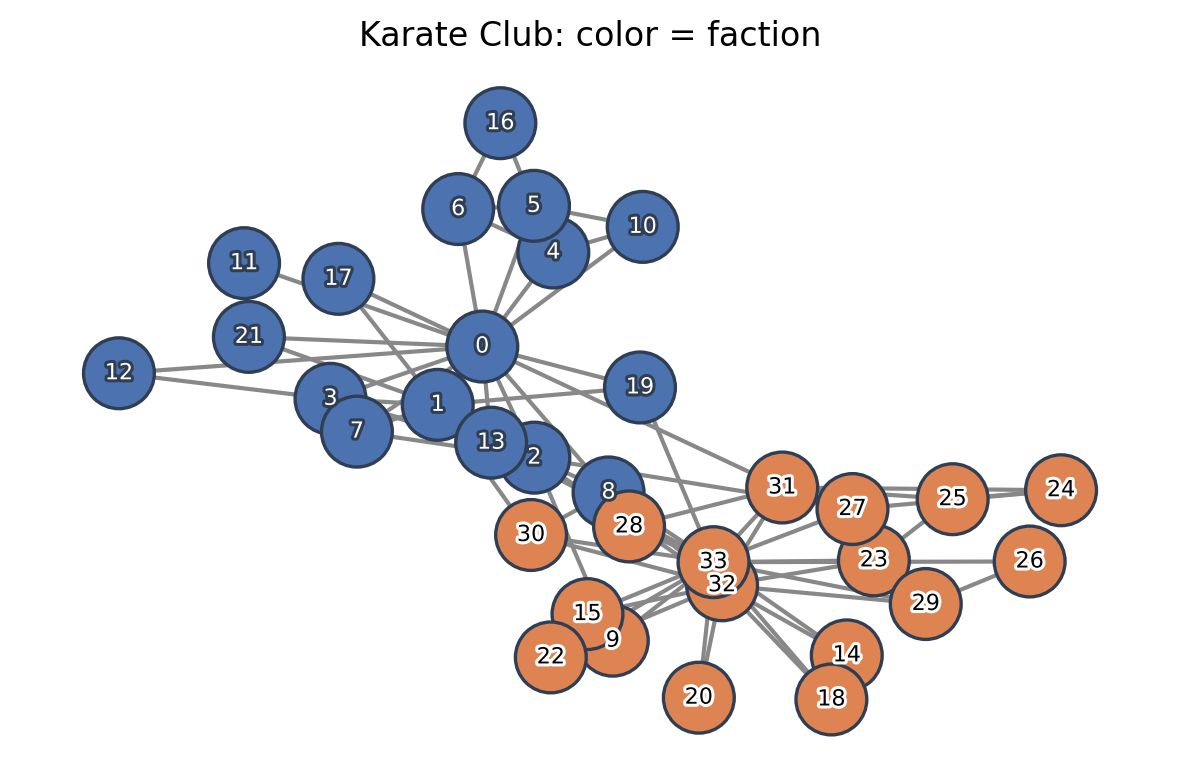

p = 0.500, q = 0.500
2pq baseline             = 0.5000
Observed cross-edge rate = 0.1410 (11/78)
Homophily detected       = True


In [3]:
karate = nx.karate_club_graph()
pos_karate = nx.spring_layout(karate, seed=RANDOM_SEED)
clubs = nx.get_node_attributes(karate, 'club')

plot_graph(
    karate,
    title='Karate Club: color = faction',
    pos=pos_karate,
    with_labels=True,
    node_color=colors_from_node_attribute(karate, 'club', KARATE_CLUB_COLORS),
    node_size=650,
    font_size=8,
    figure_size=FIGURE_SIZE_SMALL,
)

p = sum(club == 'Mr. Hi' for club in clubs.values()) / karate.number_of_nodes()
q = 1 - p
baseline = 2 * p * q
frac_cross, cross_count = cross_type_fraction(karate, clubs)

print(f'p = {p:.3f}, q = {q:.3f}')
print(f'2pq baseline             = {baseline:.4f}')
print(f'Observed cross-edge rate = {frac_cross:.4f} ({cross_count}/{karate.number_of_edges()})')
print(f'Homophily detected       = {frac_cross < baseline}')

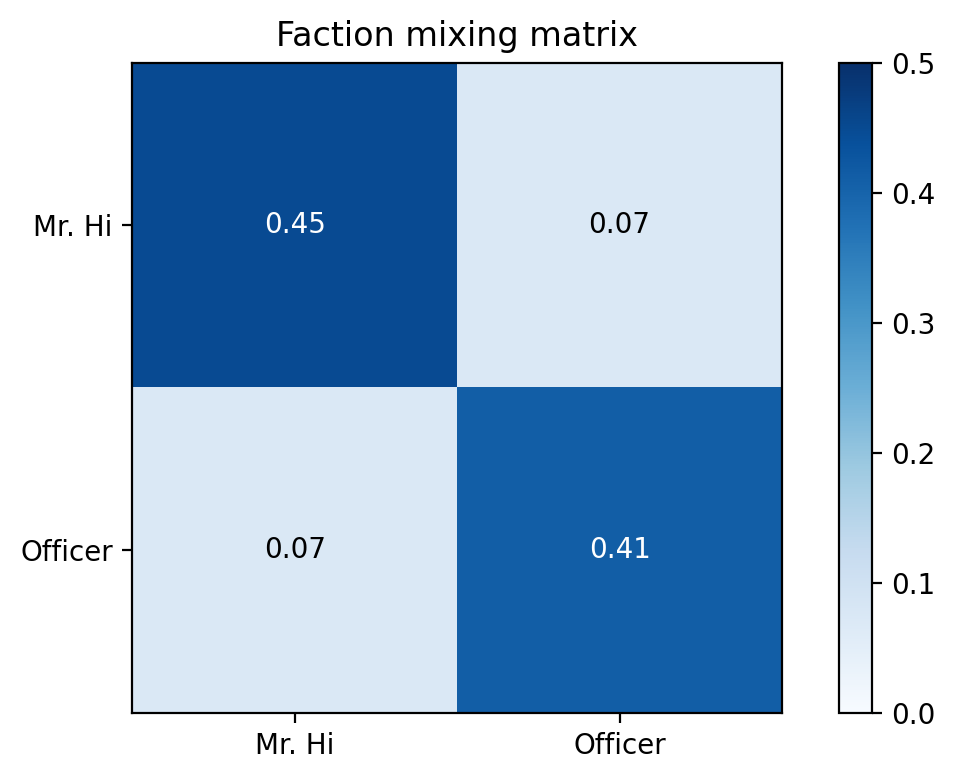

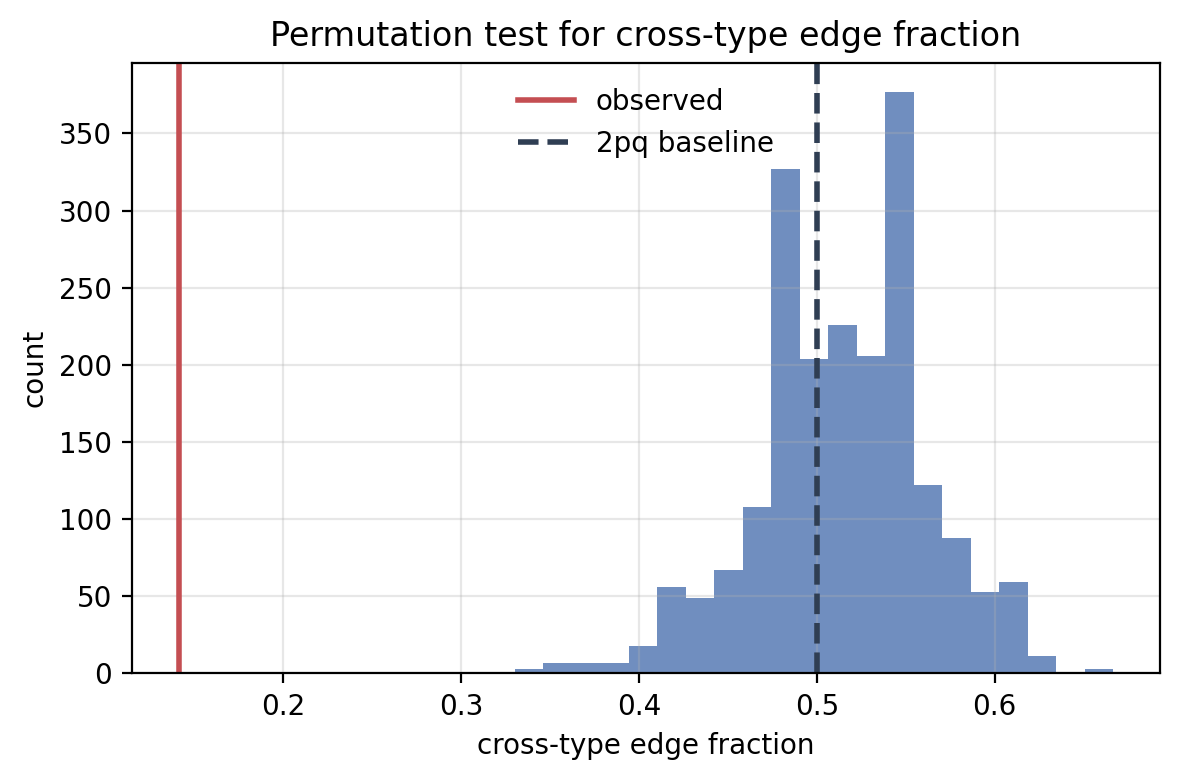

Permutation p-value (left tail) = 0.0005


In [4]:
mixing = nx.attribute_mixing_matrix(karate, 'club', normalized=True)
plot_heatmap(
    mixing,
    labels=['Mr. Hi', 'Officer'],
    title='Faction mixing matrix',
    vmin=0,
    vmax=0.5,
)
plt.show()

observed, null_values, p_value = permutation_homophily_test(karate, clubs, n_perm=2000)
fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
ax.hist(null_values, bins=24, color=CATEGORY_PALETTE['blue'], alpha=0.8)
ax.axvline(observed, color=HIGHLIGHT_COLOR, linewidth=2, label='observed')
ax.axvline(baseline, color=TREND_COLOR, linewidth=2, linestyle='--', label='2pq baseline')
style_axis(
    ax,
    title='Permutation test for cross-type edge fraction',
    xlabel='cross-type edge fraction',
    ylabel='count',
    legend=True,
)
plt.show()

print(f'Permutation p-value (left tail) = {p_value:.4f}')

**Interpretation.**

- The observed network has fewer cross-faction edges than random relabelings of the same graph.
- This is computational evidence of homophily in the snapshot.
- But it does **not** tell us whether the mechanism is **selection** or **social influence**. That distinction requires longitudinal data, exactly as stressed in the lecture.

Real-world implication: in schools, teams, and online communities, strong homophily can concentrate trust, information, and opportunities within groups.

---
## 2. Degree assortativity and neighbor-degree profiles

The lecture defines

$$
k_{nn}(i) = \frac{1}{k_i} \sum_j A_{ij}k_j
$$

and the degree correlation function

$$
k_{nn}(k) = \langle k_{nn}(i) \rangle_{i:\,k_i = k}.
$$

Computationally, these two objects complement the scalar assortativity coefficient $r$:

- $r$ gives one summary number
- $k_{nn}(k)$ shows **how** neighbor degree changes across the degree range

### 2.1 Manual check on the lecture toy graph

In [5]:
toy = nx.Graph([(0, 1), (0, 2), (0, 3), (1, 2), (2, 3)])
_, _, k_nn_i = knn_by_degree(toy)

rows = []
for node in sorted(toy.nodes()):
    rows.append({
        'node': node,
        'degree': toy.degree(node),
        'k_nn(i)': k_nn_i[node],
    })
print(pd.DataFrame(rows).round(4).to_string(index=False))
print('\nExpected values from the slide example:')
print(f"k_nn(0) = 5/3 = {5/3:.4f}")
print('k_nn(1) = 3.0')
print(f"k_nn(2) = 5/2 = {5/2:.4f}")
print(f"k_nn(3) = 5/2 = {5/2:.4f}")

 node  degree  k_nn(i)
    0       3   2.3333
    1       2   3.0000
    2       3   2.3333
    3       2   3.0000

Expected values from the slide example:
k_nn(0) = 5/3 = 1.6667
k_nn(1) = 3.0
k_nn(2) = 5/2 = 2.5000
k_nn(3) = 5/2 = 2.5000


### 2.2 Three network types

The goal here is computational: reproduce the qualitative patterns from the lecture and see how $k_{nn}(k)$ and $r$ behave together.

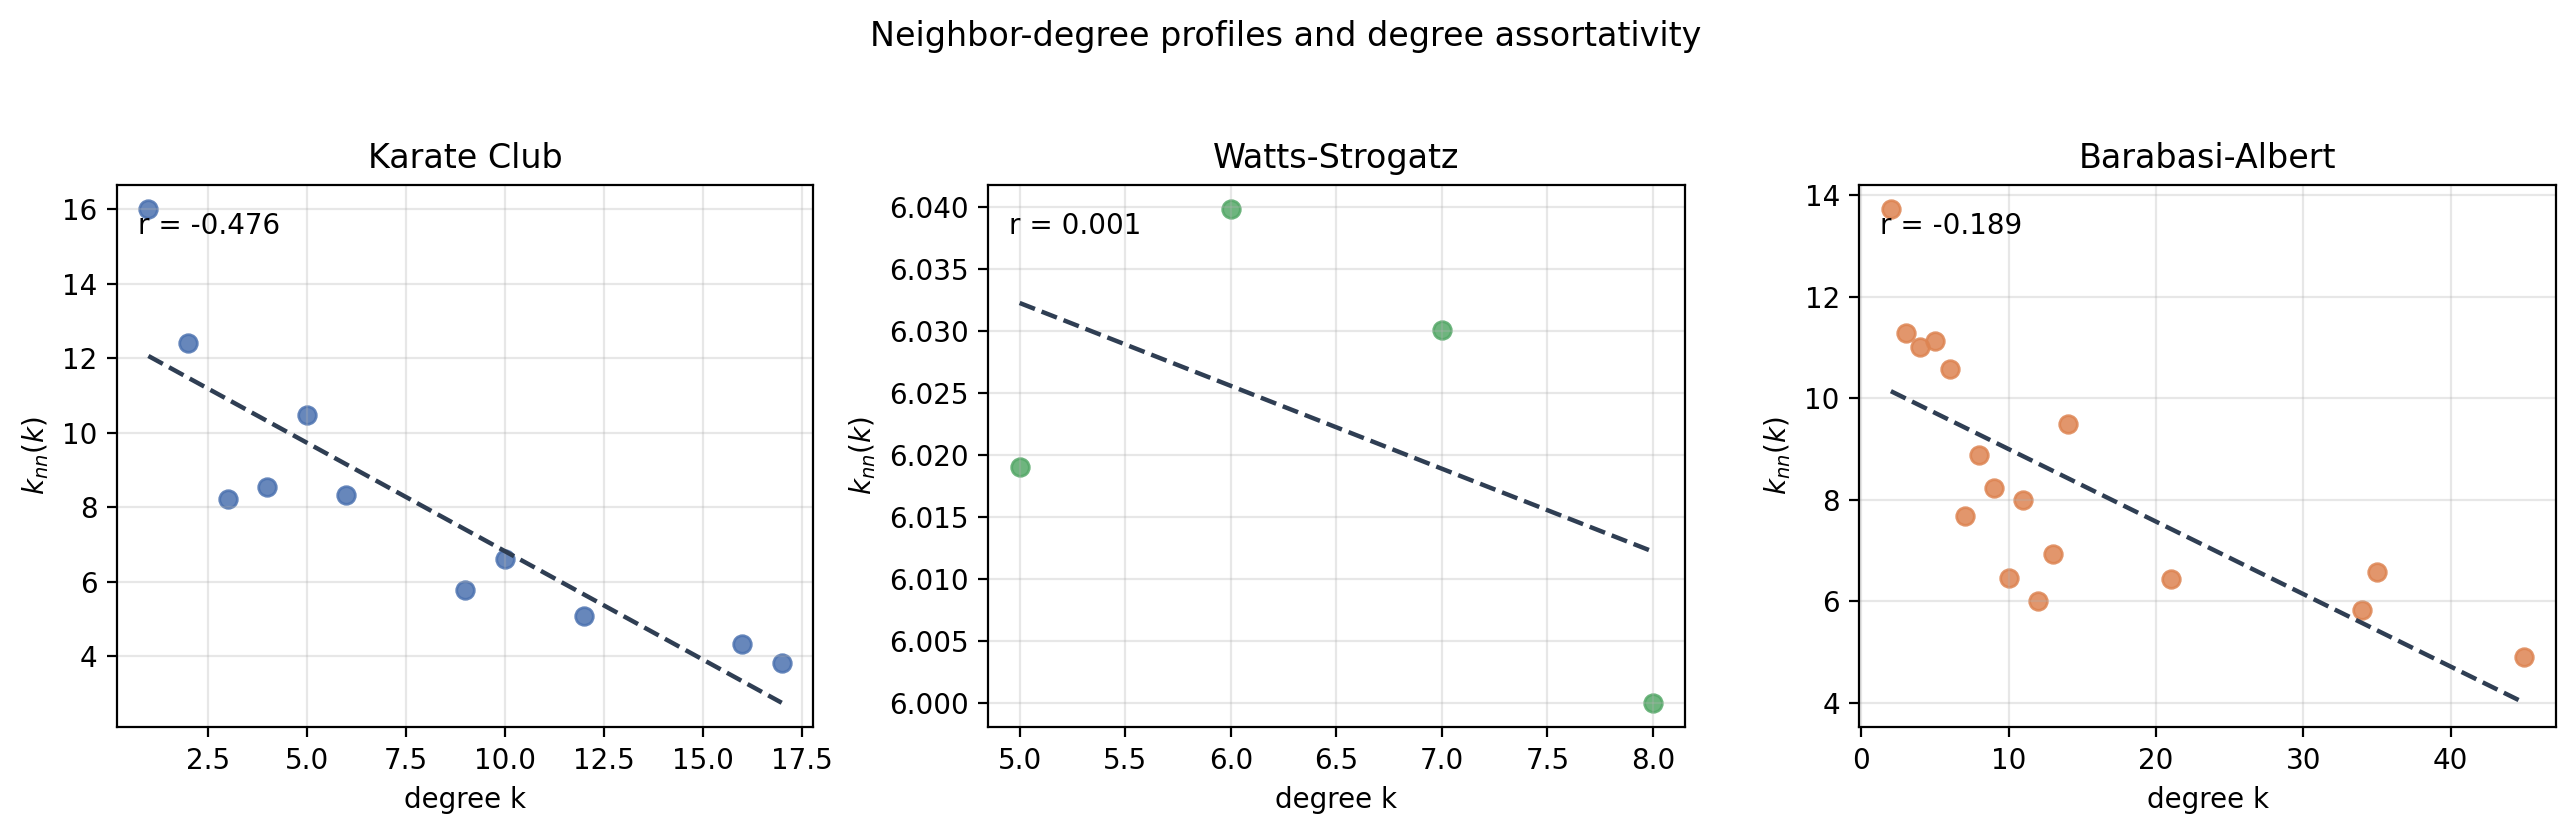

        network       r   slope
    Karate Club -0.4756 -0.5824
 Watts-Strogatz  0.0014 -0.0067
Barabasi-Albert -0.1888 -0.1428


In [6]:
networks = [
    ('Karate Club', nx.karate_club_graph(), CATEGORY_PALETTE['blue']),
    ('Watts-Strogatz', nx.watts_strogatz_graph(200, 6, 0.05, seed=RANDOM_SEED), CATEGORY_PALETTE['green']),
    ('Barabasi-Albert', nx.barabasi_albert_graph(200, 2, seed=RANDOM_SEED), CATEGORY_PALETTE['orange']),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
summary_rows = []

for ax, (name, H, color) in zip(axes, networks):
    ks, means, _ = knn_by_degree(H)
    ax.scatter(ks, means, color=color, s=40, alpha=0.85)
    if len(ks) > 1:
        slope, intercept = np.polyfit(ks, means, 1)
        xline = np.linspace(ks.min(), ks.max(), 100)
        ax.plot(xline, slope * xline + intercept, linestyle='--', color=TREND_COLOR, linewidth=1.6)
    else:
        slope = np.nan
    r = nx.degree_assortativity_coefficient(H)
    style_axis(ax, title=name, xlabel='degree k', ylabel='$k_{nn}(k)$')
    ax.text(0.03, 0.95, f'r = {r:.3f}', transform=ax.transAxes, va='top')
    summary_rows.append({'network': name, 'r': r, 'slope': slope})

plt.suptitle('Neighbor-degree profiles and degree assortativity', y=1.03)
plt.tight_layout()
plt.show()

print(pd.DataFrame(summary_rows).round(4).to_string(index=False))

**Interpretation.**

- Positive slope / positive $r$: high-degree nodes tend to connect to high-degree nodes.
- Flat profile / $r \approx 0$: no clear degree correlation.
- Negative slope / negative $r$: hubs connect mainly to low-degree nodes.

Real-world implication: assortative social networks can reinforce elite cores, while disassortative technological or biological networks often organize around hub-and-spoke backbones.

---
## 3. Schelling segregation as a computational process

The lecture argument is dynamic, not only static.

Agents do not choose global segregation directly. They follow a **local threshold rule**:

- an agent is satisfied if at least $t$ of its 8 neighbors are of the same type
- otherwise it moves to a random empty cell

The computational question is whether local updates amplify into global spatial segregation.

In [7]:
class SchellingModel:
    EMPTY = 0
    TYPE1 = 1
    TYPE2 = 2

    def __init__(self, grid_size=30, n_agents=700, t=3, frac_type1=0.5, seed=RANDOM_SEED):
        rng = np.random.default_rng(seed)
        self.size = grid_size
        self.t = t
        self.rng = rng

        cells = np.zeros(grid_size**2, dtype=int)
        n1 = int(n_agents * frac_type1)
        n2 = n_agents - n1
        cells[:n1] = self.TYPE1
        cells[n1:n1 + n2] = self.TYPE2
        rng.shuffle(cells)
        self.grid = cells.reshape(grid_size, grid_size)

    def _neighbor_counts(self, r, c):
        agent_type = self.grid[r, c]
        same = 0
        occupied = 0
        for dr in [-1, 0, 1]:
            for dc in [-1, 0, 1]:
                if dr == 0 and dc == 0:
                    continue
                nr, nc = (r + dr) % self.size, (c + dc) % self.size
                neighbor = self.grid[nr, nc]
                if neighbor != self.EMPTY:
                    occupied += 1
                    if neighbor == agent_type:
                        same += 1
        return same, occupied

    def step(self):
        rows, cols = np.where(self.grid != self.EMPTY)
        order = self.rng.permutation(len(rows))
        empty_rows, empty_cols = np.where(self.grid == self.EMPTY)
        empty_cells = list(zip(empty_rows, empty_cols))
        self.rng.shuffle(empty_cells)

        moved = 0
        for idx in order:
            r, c = rows[idx], cols[idx]
            if self.grid[r, c] == self.EMPTY:
                continue
            same, _ = self._neighbor_counts(r, c)
            if same < self.t and empty_cells:
                nr, nc = empty_cells.pop()
                self.grid[nr, nc] = self.grid[r, c]
                self.grid[r, c] = self.EMPTY
                empty_cells.append((r, c))
                moved += 1
        return moved

    def satisfaction_rate(self):
        rows, cols = np.where(self.grid != self.EMPTY)
        if len(rows) == 0:
            return 1.0
        satisfied = 0
        for r, c in zip(rows, cols):
            same, _ = self._neighbor_counts(r, c)
            if same >= self.t:
                satisfied += 1
        return satisfied / len(rows)

    def segregation_index(self):
        rows, cols = np.where(self.grid != self.EMPTY)
        shares = []
        for r, c in zip(rows, cols):
            same, occupied = self._neighbor_counts(r, c)
            if occupied > 0:
                shares.append(same / occupied)
        return float(np.mean(shares)) if shares else 1.0

    def run(self, rounds):
        history = [{'round': 0, 'satisfaction': self.satisfaction_rate(), 'segregation': self.segregation_index()}]
        for step in range(1, rounds + 1):
            self.step()
            history.append({'round': step, 'satisfaction': self.satisfaction_rate(), 'segregation': self.segregation_index()})
        return pd.DataFrame(history)


def draw_schelling_grid(ax, grid, title):
    ax.imshow(grid, cmap=SCHELLING_CMAP, vmin=0, vmax=2, interpolation='nearest')
    ax.set_title(title)
    ax.axis('off')

### 3.1 Match the lecture case: threshold $t=3$

The lecture emphasizes the surprising case $t = 3$: agents are satisfied even when they are a minority locally, yet segregation still emerges.

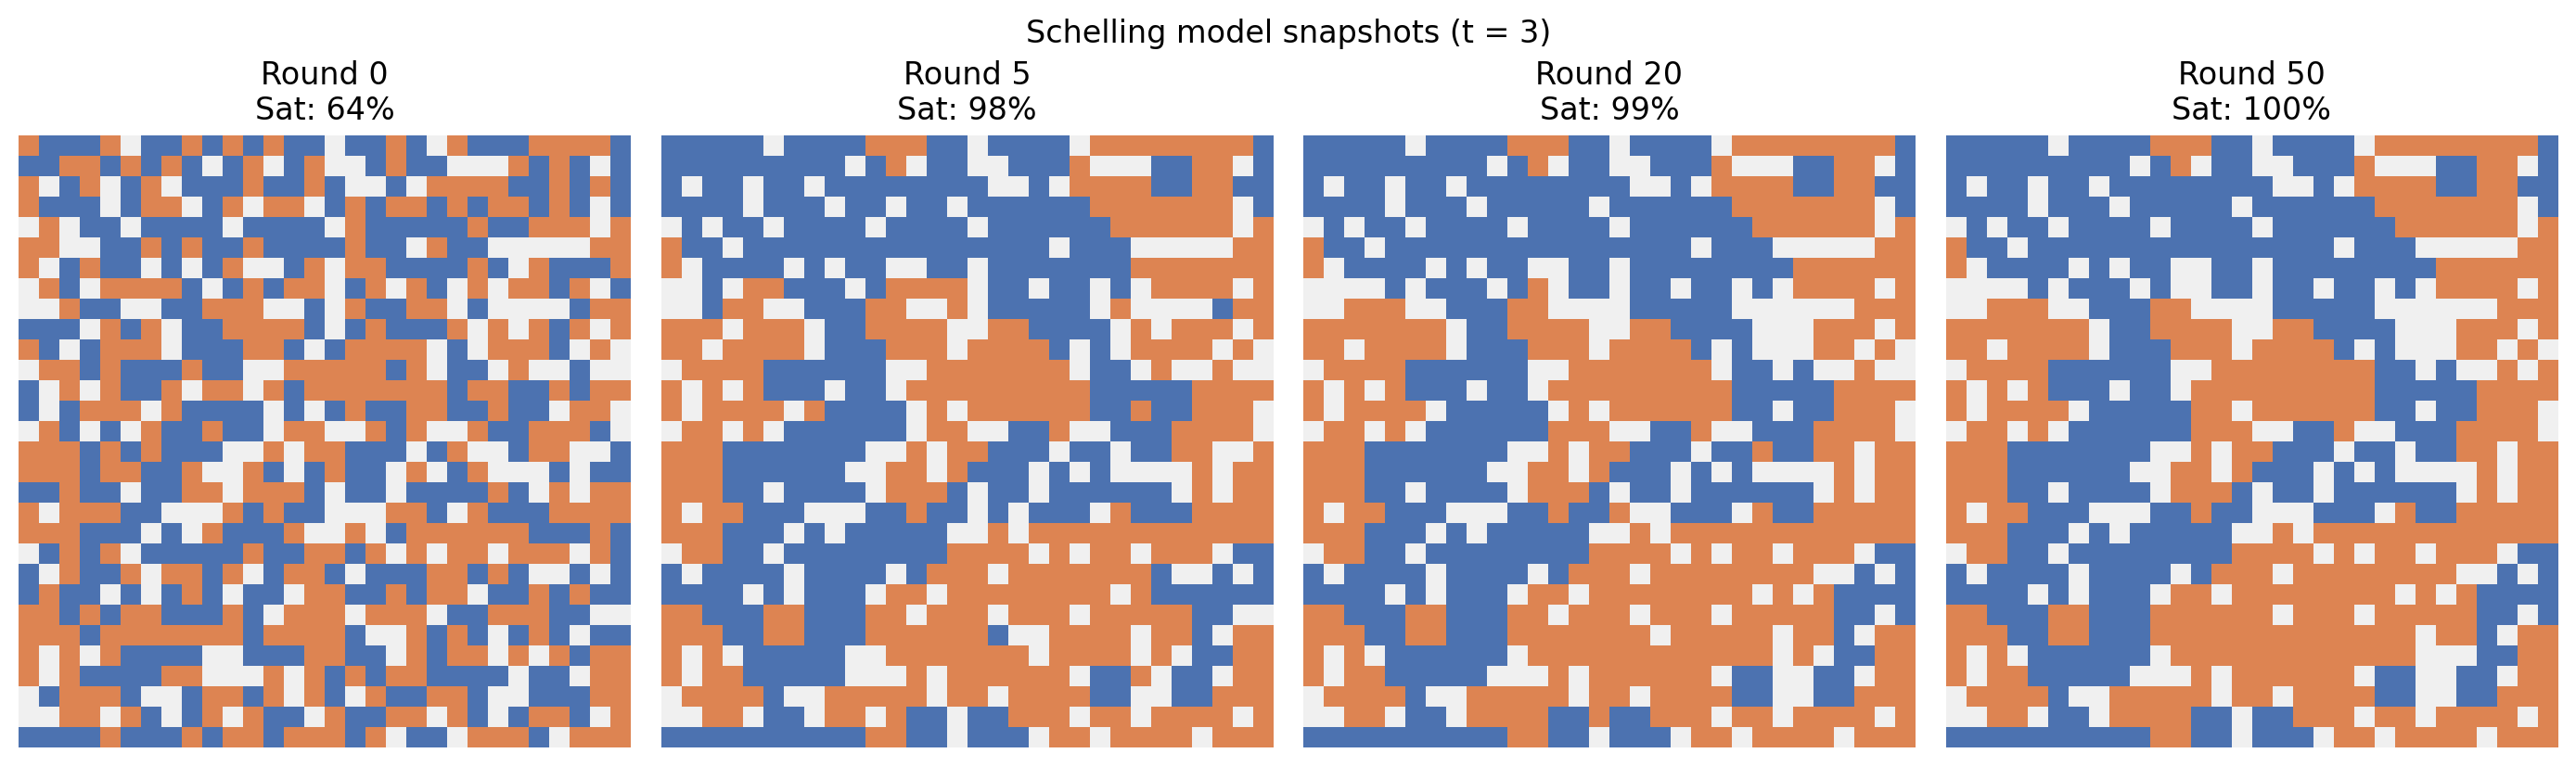

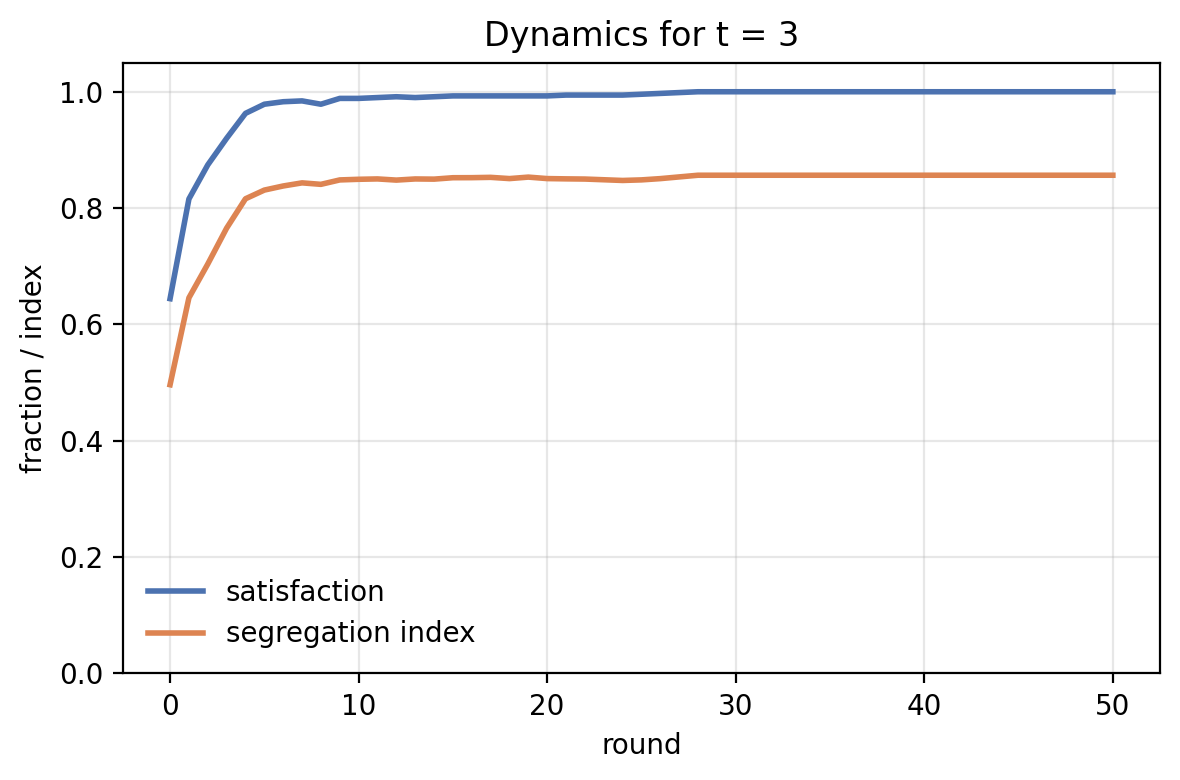

 round  satisfaction  segregation
    46           1.0       0.8565
    47           1.0       0.8565
    48           1.0       0.8565
    49           1.0       0.8565
    50           1.0       0.8565


In [8]:
model = SchellingModel(grid_size=30, n_agents=700, t=3, frac_type1=0.5, seed=RANDOM_SEED)
snapshots = {0: model.grid.copy()}
history = [{'round': 0, 'satisfaction': model.satisfaction_rate(), 'segregation': model.segregation_index()}]

for round_idx in range(1, 51):
    model.step()
    history.append({'round': round_idx, 'satisfaction': model.satisfaction_rate(), 'segregation': model.segregation_index()})
    if round_idx in {5, 20, 50}:
        snapshots[round_idx] = model.grid.copy()

history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, round_idx in zip(axes, [0, 5, 20, 50]):
    sat = history_df.loc[history_df['round'] == round_idx, 'satisfaction'].iloc[0]
    draw_schelling_grid(ax, snapshots[round_idx], title=f'Round {round_idx}\nSat: {sat:.0%}')
plt.suptitle('Schelling model snapshots (t = 3)', y=1.02)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
ax.plot(history_df['round'], history_df['satisfaction'], color=CATEGORY_PALETTE['blue'], linewidth=2, label='satisfaction')
ax.plot(history_df['round'], history_df['segregation'], color=CATEGORY_PALETTE['orange'], linewidth=2, label='segregation index')
style_axis(ax, title='Dynamics for t = 3', xlabel='round', ylabel='fraction / index', legend=True)
ax.set_ylim(0, 1.05)
plt.show()

print(history_df.tail().round(4).to_string(index=False))

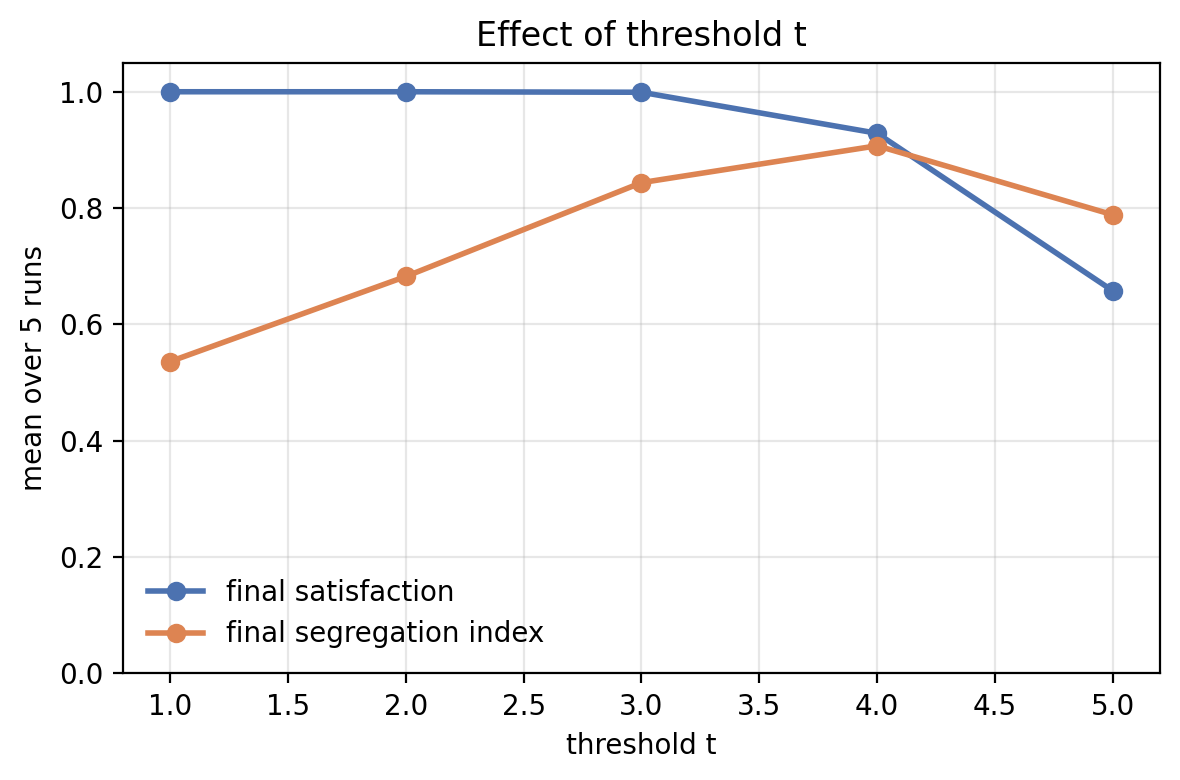

 t  rep  final_satisfaction  final_segregation
 1  2.0              1.0000             0.5361
 2  2.0              1.0000             0.6824
 3  2.0              0.9991             0.8437
 4  2.0              0.9286             0.9072
 5  2.0              0.6577             0.7884


In [9]:
results = []
for t in [1, 2, 3, 4, 5]:
    for rep in range(5):
        m = SchellingModel(grid_size=30, n_agents=700, t=t, frac_type1=0.5, seed=RANDOM_SEED + rep)
        hist = m.run(50)
        results.append({
            't': t,
            'rep': rep,
            'final_satisfaction': hist['satisfaction'].iloc[-1],
            'final_segregation': hist['segregation'].iloc[-1],
        })

threshold_df = pd.DataFrame(results)
threshold_summary = threshold_df.groupby('t', as_index=False).mean(numeric_only=True)

fig, ax = plt.subplots(figsize=FIGURE_SIZE_SMALL)
ax.plot(threshold_summary['t'], threshold_summary['final_satisfaction'], marker='o', linewidth=2, color=CATEGORY_PALETTE['blue'], label='final satisfaction')
ax.plot(threshold_summary['t'], threshold_summary['final_segregation'], marker='o', linewidth=2, color=CATEGORY_PALETTE['orange'], label='final segregation index')
style_axis(ax, title='Effect of threshold t', xlabel='threshold t', ylabel='mean over 5 runs', legend=True)
ax.set_ylim(0, 1.05)
plt.show()

print(threshold_summary.round(4).to_string(index=False))

**Interpretation.**

- As the threshold $t$ increases, segregation becomes stronger.
- The model makes the lecture point computationally explicit: local satisfaction rules create global spatial structure.

Real-world implication: urban segregation or school segregation can emerge from local behavior that does not explicitly ask for a fully segregated city.

---
## 4. Signed balance and polarization

The lecture defines a signed triangle as **balanced** if the product of its edge signs is positive.

Equivalent rule:

- balanced triangles have an **even number of negative edges**
- weak balance allows the all-negative triangle but still forbids exactly one negative edge

Computationally, this means we can classify each triangle and test whether a signed graph is strongly balanced, weakly balanced, or neither.

In [10]:
camp_colors = {
    'A': CATEGORY_PALETTE['blue'],
    'B': CATEGORY_PALETTE['orange'],
    'C': CATEGORY_PALETTE['green'],
}

two_camp = build_signed_complete_graph({0: 'A', 1: 'A', 2: 'A', 3: 'B', 4: 'B', 5: 'B'})
three_camp = build_signed_complete_graph({0: 'A', 1: 'A', 2: 'B', 3: 'B', 4: 'C', 5: 'C'})
frustrated = two_camp.copy()
frustrated.edges[0, 1]['sign'] = -1

summary_rows = []
for name, G_signed in [('two camps', two_camp), ('three camps', three_camp), ('frustrated example', frustrated)]:
    triads = signed_triangle_table(G_signed)
    summary_rows.append({
        'graph': name,
        'n_triangles': len(triads),
        'all_balanced': bool(triads['balanced'].all()),
        'all_weakly_balanced': bool(triads['weakly_balanced'].all()),
        'unbalanced_triangles': int((~triads['balanced']).sum()),
    })

print(pd.DataFrame(summary_rows).to_string(index=False))

             graph  n_triangles  all_balanced  all_weakly_balanced  unbalanced_triangles
         two camps           20          True                 True                     0
       three camps           20         False                 True                     8
frustrated example           20         False                False                     4


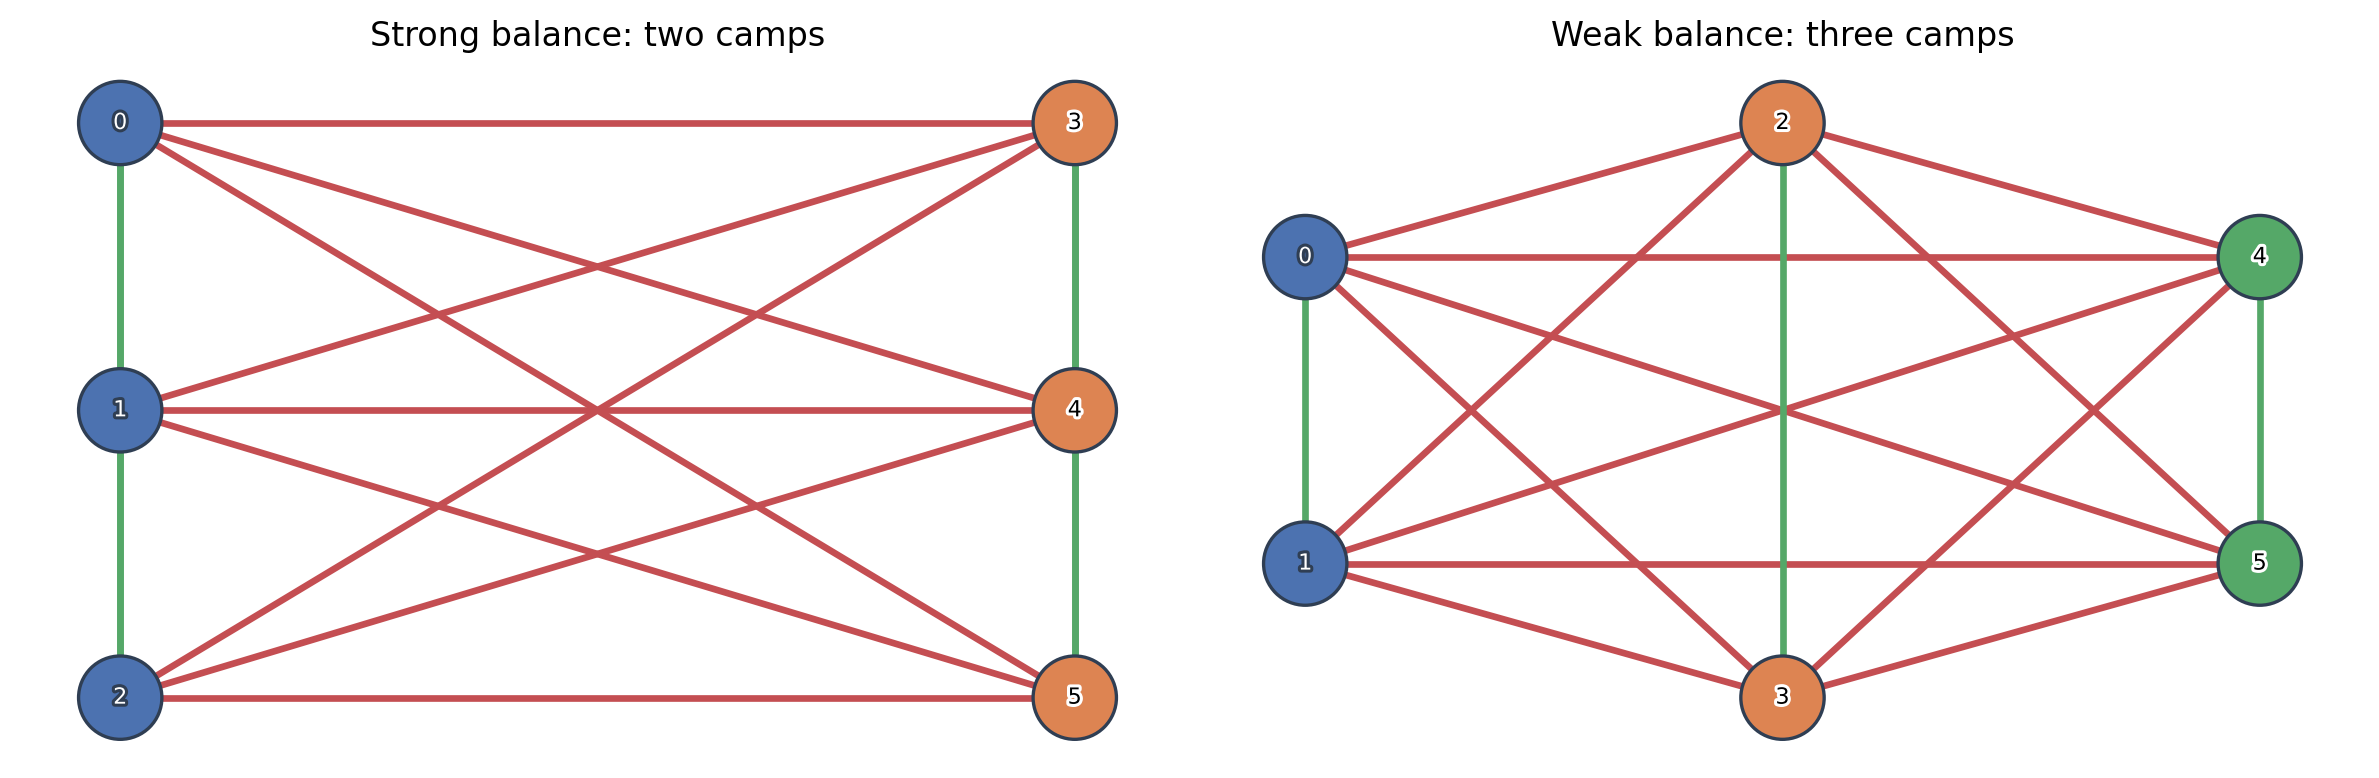

Two-camp triangle counts:
negative_edges  balanced
0               True         2
2               True        18

Three-camp triangle counts:
negative_edges  balanced  weakly_balanced
2               True      True               12
3               False     True                8


In [11]:
pos_two = {0: (-1.2, 1.0), 1: (-1.2, 0.0), 2: (-1.2, -1.0), 3: (1.2, 1.0), 4: (1.2, 0.0), 5: (1.2, -1.0)}
pos_three = {0: (-1.8, 0.8), 1: (-1.8, -0.8), 2: (0.0, 1.5), 3: (0.0, -1.5), 4: (1.8, 0.8), 5: (1.8, -0.8)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
draw_signed_graph(two_camp, pos_two, axes[0], 'Strong balance: two camps', camp_colors)
draw_signed_graph(three_camp, pos_three, axes[1], 'Weak balance: three camps', camp_colors)
plt.tight_layout()
plt.show()

print('Two-camp triangle counts:')
print(signed_triangle_table(two_camp).groupby(['negative_edges', 'balanced']).size().to_string())
print('\nThree-camp triangle counts:')
print(signed_triangle_table(three_camp).groupby(['negative_edges', 'balanced', 'weakly_balanced']).size().to_string())

**Interpretation.**

- The two-camp graph satisfies the strong balance theorem: all within-group ties are positive and all cross-group ties are negative.
- The three-camp graph is **not** strongly balanced because it contains triangles with three negative edges, but it is **weakly balanced**.
- The frustrated example shows how a single wrong sign can generate locally unstable triangles.

Real-world implication: signed online platforms, alliance systems, and polarized communities can be studied as computational balance problems, not only as metaphors.

## Takeaway

- The **homophily test** compares observed mixing to the random-mixing baseline $2pq$.
- A **permutation test** turns that baseline into a computational null model on an observed graph.
- **$k_{nn}(k)$** and **$r$** describe assortative, neutral, and disassortative structure.
- The **Schelling model** shows how local thresholds create global segregation.
- **Structural balance** and **weak balance** connect local signed triangles to global faction structure.

What a snapshot can measure well: mixing, assortativity, segregation, and signed balance.  
What a snapshot cannot settle on its own: whether homophily comes from **selection** or **social influence**.